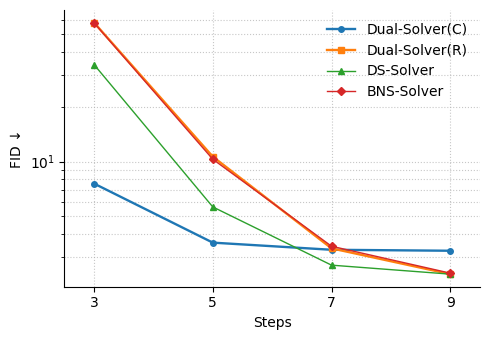

In [5]:
# Plot inline, with Dual-Solver emphasized (thicker line + bold legend label)
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, FuncFormatter, NullFormatter

# Data
steps = np.array([3, 5, 7, 9])
results = {
    "Dual-Solver(C)":  np.array([7.58, 3.59, 3.28, 3.24]),
    "Dual-Solver(R)":  np.array([58.06, 10.65, 3.34, 2.41]),
    "DS-Solver":       np.array([34.15, 5.64, 2.7, 2.41]),
    "BNS-Solver":      np.array([57.88, 10.31, 3.43, 2.44]),
}

fig, ax = plt.subplots(figsize=(5, 3.5))
markers = ["o", "s", "^", "D", "P"]
lines = {}

for i, (label, vals) in enumerate(results.items()):
    lw = 1.7 if "Dual-Solver" in label else 1.0
    (line,) = ax.plot(
        steps, vals,
        marker=markers[i],
        linewidth=lw,
        markersize=4,
        label=label,
    )
    lines[label] = line

ax.set_xlabel("Steps")
ax.set_ylabel("FID ↓")
ax.set_xticks(steps)
ax.set_xlim(2.5, 9.5)

# # Log scale with numeric labels (10, 100) and dense minor ticks
ax.set_yscale("log")
# ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
# ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=tuple(range(2, 10)), numticks=100))

def major_fmt(y, pos):
    if y in (1, 10, 100, 1000):
        return f"{int(y)}"
    return ""
# ax.yaxis.set_major_formatter(FuncFormatter(major_fmt))
# ax.yaxis.set_minor_formatter(NullFormatter())
# ax.tick_params(axis="y", which="major", length=6, width=1.2)
# ax.tick_params(axis="y", which="minor", length=3, width=0.8)

# Grid & aesthetics
ax.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend: keep order, bold the Dual-Solver label
legend = ax.legend(handles=[lines[k] for k in results.keys()], frameon=False, loc="upper right")
for txt in legend.get_texts():
    if txt.get_text() == "Dual-Solver":
        txt.set_fontweight("bold")

fig.tight_layout()
plt.show()
